# Inference Batch — Year-wise Mining Detection (Averaged)
**Notebook:** `inference_batch.ipynb`

Runs the same inference pipeline as `inference_visualizer.ipynb` but loops through
every JP2 file year by year and **averages all scenes per year** (Option B — most rigorous).

### Why average instead of picking one scene?
- Removes seasonal bias — one cloudy scene won't skew the year's result
- More defensible in paper review — reviewer cannot say "you cherry-picked the best scene"
- Smooths out acquisition noise across multiple dates

### What it saves (per year, averaged across all scenes)
```
inference_output/temporal/
  2021_overlay.png          ← overlay from the median scene (for visual reference)
  2021_heatmap.png          ← AVERAGED probability heatmap across all scenes
  2021_result.json          ← averaged stats (mean area, std dev, n_scenes)
  2022_overlay.png
  2022_heatmap.png
  2022_result.json
  ... (one set per year)
  all_scenes_results.csv    ← every individual scene result
  yearly_summary.csv        ← averaged per-year summary → read by temporal_analysis.ipynb
```

**Then run `temporal_analysis.ipynb`** which reads these results and makes charts.


## Cell 1 — Imports

In [1]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

try:
    import rasterio
    from rasterio.transform import xy as rio_xy
    from rasterio.crs import CRS
    from rasterio.enums import Resampling
    HAS_RASTERIO = True
    print('rasterio OK')
except ImportError:
    HAS_RASTERIO = False
    print('rasterio not found — install: pip install rasterio')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))


rasterio OK
Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 — Config
> **Only update `DATA_ROOT`** — everything else is auto-detected.

In [2]:
# ── Folder containing your year subfolders ───────────────────────────────
DATA_ROOT = r"R:\ai project image\data image big"

# ── Year folder names → year labels ──────────────────────────────────────
YEAR_MAP = {
    'big 2021' : 2021,
    '2022'     : 2022,
    '2023'     : 2023,
    '2024'     : 2024,
    '2025'     : 2025,
}

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_PATH  = 'saved_models/best_model.pth'
NUM_CLASSES = 2

# ── Patch settings ────────────────────────────────────────────────────────
PATCH_SIZE  = 64      # must match training patch size
STRIDE      = 32      # 50% overlap
THRESHOLD   = 0.6     # raised from 0.5 → reduces false positives on large scenes
BATCH_SIZE  = 64

# ── Sentinel-2 native resolution ─────────────────────────────────────────
NATIVE_RES_M = 10.0   # metres per pixel at native resolution

# ── Output ────────────────────────────────────────────────────────────────
OUTPUT_DIR  = 'inference_output/temporal'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aggregation strategy: AVERAGE ALL SCENES PER YEAR ────────────────────
# Option B (most rigorous) — averages area_km2 and coverage_pct across
# all scenes in a year. Removes seasonal bias and is more defensible
# in paper review. The representative overlay image is the scene whose
# area is closest to the year mean (median scene).
AGGREGATION = 'average'   # do not change

MAX_DIM = 5000

print(f'Data root    : {DATA_ROOT}')
print(f'Model        : {MODEL_PATH}')
print(f'Output       : {OUTPUT_DIR}')
print(f'Patch size   : {PATCH_SIZE}px  Stride: {STRIDE}px  Threshold: {THRESHOLD}')
print(f'Native res   : {NATIVE_RES_M}m/px')
print(f'Aggregation  : {AGGREGATION} (Option B — average all scenes per year)')

for folder, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    path  = os.path.join(DATA_ROOT, folder)
    files = glob.glob(os.path.join(path, '*.jp2'))
    status = f'{len(files)} JP2 files' if files else 'NOT FOUND'
    print(f'  {year} ({folder}): {status}')


Data root    : R:\ai project image\data image big
Model        : saved_models/best_model.pth
Output       : inference_output/temporal
Patch size   : 64px  Stride: 32px  Threshold: 0.6
Native res   : 10.0m/px
Aggregation  : average (Option B — average all scenes per year)
  2021 (big 2021): 6 JP2 files
  2022 (2022): 7 JP2 files
  2023 (2023): 6 JP2 files
  2024 (2024): 4 JP2 files
  2025 (2025): 6 JP2 files


## Cell 3 — Load Model

In [3]:
def load_efficientnet_b0(model_path):
    """Load EfficientNet-B0 — matches your training setup exactly."""
    model = models.efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.to(device).eval()
    print(f'Model loaded: {model_path}')
    return model

model = load_efficientnet_b0(MODEL_PATH)

# Transform — resize patch to 224x224 for EfficientNet
patch_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
print('Patch transform ready.')


Model loaded: saved_models/best_model.pth
Patch transform ready.


## Cell 4 — Core Functions
(Same logic as inference_visualizer.ipynb — just packaged as reusable functions)

In [4]:
def load_jp2(path, max_dim=MAX_DIM):
    """Load a Sentinel-2 JP2/GeoTIFF, downsample if too large, return RGB uint8."""
    if HAS_RASTERIO:
        with rasterio.open(path) as src:
            h, w = src.height, src.width
            scale = min(1.0, max_dim / max(h, w))
            nh, nw = int(h * scale), int(w * scale)
            data = src.read(
                out_shape=(src.count, nh, nw),
                resampling=Resampling.bilinear
            )
            geo_transform = src.transform
            crs = src.crs
        # (bands, H, W) → (H, W, 3)
        data = np.moveaxis(data[:3], 0, -1).astype(np.float32)
        for i in range(3):
            p2, p98 = np.percentile(data[:,:,i], (2, 98))
            data[:,:,i] = np.clip((data[:,:,i]-p2)/(p98-p2+1e-8), 0, 1)
        return (data*255).astype(np.uint8), geo_transform, crs, scale
    else:
        img = Image.open(path).convert('RGB')
        img.thumbnail((max_dim, max_dim))
        return np.array(img), None, None, 1.0


def run_inference(img_rgb, patch_size=PATCH_SIZE, stride=STRIDE,
                  threshold=THRESHOLD, batch_size=BATCH_SIZE):
    """
    Sliding window inference. Returns:
      prob_map    : (H,W) float32 — mining probability per pixel
      mining_mask : (H,W) bool    — True where mining detected
      detections  : list of {pixel_y, pixel_x, confidence}
      n_total     : total patches scanned
    """
    H, W = img_rgb.shape[:2]
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    detections = []

    positions = [(y, x)
                 for y in range(0, H - patch_size + 1, stride)
                 for x in range(0, W - patch_size + 1, stride)]

    patches_buf, pos_buf = [], []

    with torch.no_grad():
        for i, (y, x) in enumerate(positions):
            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patches_buf.append(patch_transform(Image.fromarray(patch)))
            pos_buf.append((y, x))

            flush = (len(patches_buf) == batch_size) or (i == len(positions)-1)
            if flush and patches_buf:
                batch = torch.stack(patches_buf).to(device)
                probs = torch.softmax(model(batch), dim=1)[:, 0].cpu().numpy()

                for (py, px), prob in zip(pos_buf, probs):
                    prob_map [py:py+patch_size, px:px+patch_size] += prob
                    count_map[py:py+patch_size, px:px+patch_size] += 1
                    if prob >= threshold:
                        detections.append({'pixel_y': py, 'pixel_x': px,
                                           'confidence': float(prob)})
                patches_buf, pos_buf = [], []

            if (i+1) % 1000 == 0 or i == len(positions)-1:
                pct = (i+1)/len(positions)*100
                print(f'  {pct:5.1f}%  |  {i+1:,}/{len(positions):,} patches'
                      f'  |  mining so far: {len(detections):,}')

    count_map = np.maximum(count_map, 1)
    prob_map  = prob_map / count_map
    return prob_map, prob_map >= threshold, detections, len(positions)


def make_overlay(img_rgb, mining_mask):
    """Red overlay on detected mining pixels."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mining_mask, 0] = np.clip(overlay[mining_mask, 0]*0.4 + 255*0.6, 0, 255)
    overlay[mining_mask, 1] = np.clip(overlay[mining_mask, 1]*0.4,            0, 255)
    overlay[mining_mask, 2] = np.clip(overlay[mining_mask, 2]*0.4,            0, 255)
    return overlay.astype(np.uint8)


def save_overlay_fig(img_rgb, overlay, mining_mask, detections,
                     year, date_str, out_path):
    """Save side-by-side original vs overlay figure."""
    coverage = mining_mask.sum() / mining_mask.size * 100
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original — {year} ({date_str})', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Mining Detection — threshold={THRESHOLD}', fontsize=12)
    axes[1].axis('off')
    red_p  = mpatches.Patch(color='red',  alpha=0.7, label='Mining detected')
    gray_p = mpatches.Patch(color='gray', alpha=0.5, label='Non-mining')
    axes[1].legend(handles=[red_p, gray_p], loc='lower right', fontsize=10)
    axes[1].text(0.02, 0.98,
                 f'Coverage: {coverage:.1f}%\nDetections: {len(detections):,}',
                 transform=axes[1].transAxes, fontsize=10, va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.suptitle(f'Illegal Mining Detection — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved overlay: {out_path}')


def save_heatmap_fig(img_rgb, prob_map, year, out_path):
    """Save heatmap figure."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    im = axes[1].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title('Mining Confidence Heatmap', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label='Mining Probability')
    plt.suptitle(f'Confidence Heatmap — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved heatmap : {out_path}')

print('All functions defined.')


All functions defined.


## Cell 5 — Run Inference Year by Year

This loops through every year folder, processes every JP2, picks the best scene, and saves outputs.

In [5]:
yearly_results = []   # one dict per year (averaged across all scenes)
all_scenes     = []   # one dict per JP2 file (every scene)

for folder_name, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    folder_path = os.path.join(DATA_ROOT, folder_name)
    jp2_files   = sorted(glob.glob(os.path.join(folder_path, '*.jp2')))

    if not jp2_files:
        print(f'\n{year}: no JP2 files found in {folder_path} — skipping')
        continue

    print(f'\n{"="*60}')
    print(f'  Year {year}  |  {len(jp2_files)} JP2 file(s)  |  Aggregation: AVERAGE')
    print(f'{"="*60}')

    year_scenes = []

    for jp2_path in jp2_files:
        fname      = os.path.basename(jp2_path)
        date_match = re.search(r'_(\d{8})T', fname)
        date_str   = date_match.group(1) if date_match else 'unknown'
        print(f'\n  [{date_str}] {fname}')

        try:
            img_rgb, geo_tf, crs, scale = load_jp2(jp2_path)
            H, W = img_rgb.shape[:2]
            print(f'  Image size: {W}x{H} px')

            prob_map, mining_mask, detections, n_total = run_inference(img_rgb)

            n_mining      = len(detections)
            coverage      = mining_mask.sum() / mining_mask.size * 100
            pixel_size_m  = NATIVE_RES_M / scale
            mining_pixels = mining_mask.sum()
            area_km2      = (mining_pixels * pixel_size_m**2) / 1e6

            print(f'  Result: {n_mining} patches  |  {area_km2:.2f} km²  |  {coverage:.1f}%')

            scene = {
                'year'        : year,
                'date'        : date_str,
                'filename'    : fname,
                'n_mining'    : n_mining,
                'n_total'     : n_total,
                'area_km2'    : area_km2,
                'coverage_pct': coverage,
                '_img_rgb'    : img_rgb,
                '_prob_map'   : prob_map,
                '_mining_mask': mining_mask,
                '_detections' : detections,
            }
            year_scenes.append(scene)
            all_scenes.append(scene)

        except Exception as e:
            print(f'  ERROR: {e}')
            import traceback; traceback.print_exc()

    if not year_scenes:
        continue

    # ── OPTION B: Average all scenes per year ─────────────────────────────
    areas_list    = [s['area_km2']     for s in year_scenes]
    coverage_list = [s['coverage_pct'] for s in year_scenes]
    n_mining_list = [s['n_mining']     for s in year_scenes]

    mean_area     = float(np.mean(areas_list))
    std_area      = float(np.std(areas_list))
    mean_coverage = float(np.mean(coverage_list))
    std_coverage  = float(np.std(coverage_list))
    mean_n_mining = float(np.mean(n_mining_list))
    n_scenes      = len(year_scenes)

    print(f'\n  Year {year} average across {n_scenes} scene(s):')
    print(f'    Mean area     : {mean_area:.2f} ± {std_area:.2f} km²')
    print(f'    Mean coverage : {mean_coverage:.2f} ± {std_coverage:.2f} %')

    # ── Representative scene for overlay/heatmap visualisation ───────────
    # Use the scene closest to the mean area (not cherry-picked, not random)
    rep_scene = min(year_scenes, key=lambda s: abs(s['area_km2'] - mean_area))
    print(f'    Representative scene: {rep_scene["date"]} '
          f'(area={rep_scene["area_km2"]:.2f} km², closest to mean)')

    # ── Average probability heatmap across all scenes ─────────────────────
    # Resize all prob_maps to the representative scene's shape, then mean
    target_h, target_w = rep_scene['_prob_map'].shape
    prob_maps_resized = []
    for s in year_scenes:
        pm = s['_prob_map']
        if pm.shape != (target_h, target_w):
            from PIL import Image as PILImg
            pm_img = PILImg.fromarray((pm * 255).astype(np.uint8))
            pm_img = pm_img.resize((target_w, target_h), PILImg.BILINEAR)
            pm = np.array(pm_img).astype(np.float32) / 255.0
        prob_maps_resized.append(pm)

    avg_prob_map  = np.mean(prob_maps_resized, axis=0)
    avg_mask      = avg_prob_map >= THRESHOLD

    # ── Save overlay (from representative scene) + averaged heatmap ──────
    overlay = make_overlay(rep_scene['_img_rgb'], rep_scene['_mining_mask'])

    save_overlay_fig(
        rep_scene['_img_rgb'], overlay, rep_scene['_mining_mask'],
        rep_scene['_detections'], year,
        f"{rep_scene['date']} (representative of {n_scenes} scenes)",
        os.path.join(OUTPUT_DIR, f'{year}_overlay.png')
    )
    save_heatmap_fig(
        rep_scene['_img_rgb'], avg_prob_map, year,
        os.path.join(OUTPUT_DIR, f'{year}_heatmap.png')
    )

    # ── Save per-year JSON ────────────────────────────────────────────────
    result_dict = {
        'year'            : year,
        'date'            : rep_scene['date'],
        'n_scenes'        : n_scenes,
        'area_km2'        : mean_area,       # ← averaged
        'area_km2_std'    : std_area,        # ← std dev (new)
        'coverage_pct'    : mean_coverage,   # ← averaged
        'coverage_pct_std': std_coverage,    # ← std dev (new)
        'n_mining'        : int(mean_n_mining),
        'n_total'         : rep_scene['n_total'],
        'aggregation'     : 'average',
        'scene_areas'     : areas_list,      # individual scene values
    }
    json_path = os.path.join(OUTPUT_DIR, f'{year}_result.json')
    with open(json_path, 'w') as f:
        json.dump(result_dict, f, indent=2)

    yearly_results.append(result_dict)

print(f'\n{"="*60}')
print(f'  BATCH INFERENCE COMPLETE  (Option B — averaged)')
print(f'  Years processed  : {len(yearly_results)}')
print(f'  Total JP2 files  : {len(all_scenes)}')
print(f'{"="*60}')



  Year 2021  |  6 JP2 file(s)  |  Aggregation: AVERAGE

  [20210226] T45QUE_20210226T044741_TCI_10m.jp2
  Image size: 5000x5000 px
    4.2%  |  1,000/24,025 patches  |  mining so far: 78
    8.3%  |  2,000/24,025 patches  |  mining so far: 157
   12.5%  |  3,000/24,025 patches  |  mining so far: 217
   16.6%  |  4,000/24,025 patches  |  mining so far: 286
   20.8%  |  5,000/24,025 patches  |  mining so far: 392
   25.0%  |  6,000/24,025 patches  |  mining so far: 477
   29.1%  |  7,000/24,025 patches  |  mining so far: 575
   33.3%  |  8,000/24,025 patches  |  mining so far: 668
   37.5%  |  9,000/24,025 patches  |  mining so far: 745
   41.6%  |  10,000/24,025 patches  |  mining so far: 815
   45.8%  |  11,000/24,025 patches  |  mining so far: 926
   49.9%  |  12,000/24,025 patches  |  mining so far: 1,095
   54.1%  |  13,000/24,025 patches  |  mining so far: 1,325
   58.3%  |  14,000/24,025 patches  |  mining so far: 1,460
   62.4%  |  15,000/24,025 patches  |  mining so far: 1,651


## Cell 6 — Save Combined CSV

Saves all results to a single CSV that `temporal_analysis.ipynb` will read.

In [6]:
# ── All scenes CSV (every individual JP2 result) ─────────────────────────
df_all = pd.DataFrame([
    {k: v for k, v in s.items() if not k.startswith('_')}
    for s in all_scenes
])
df_all = df_all.sort_values(['year','date']).reset_index(drop=True)

all_csv = os.path.join(OUTPUT_DIR, 'all_scenes_results.csv')
df_all.to_csv(all_csv, index=False)
print(f'All scenes saved: {all_csv}')
print(df_all[['year','date','n_mining','area_km2','coverage_pct']].to_string(index=False))

# ── Yearly summary CSV (averaged values — what temporal_analysis reads) ───
df_best = pd.DataFrame(yearly_results).sort_values('year').reset_index(drop=True)
df_best['change_km2'] = df_best['area_km2'].diff()
df_best['change_pct'] = df_best['area_km2'].pct_change() * 100

best_csv = os.path.join(OUTPUT_DIR, 'yearly_summary.csv')
df_best.to_csv(best_csv, index=False)
print(f'\nYearly summary (averaged) saved: {best_csv}')

print(f'\n{"="*68}')
print(f'  YEAR-WISE SUMMARY  (Option B — averaged across all scenes)')
print(f'{"="*68}')
print(f'{"Year":<6} {"Scenes":<8} {"Area km²":<18} {"Coverage %":<20} {"Change"}')
print('-'*68)
for _, row in df_best.iterrows():
    area_str = f"{row['area_km2']:.2f} ± {row['area_km2_std']:.2f}"
    cov_str  = f"{row['coverage_pct']:.2f} ± {row['coverage_pct_std']:.2f}"
    chg = (f"{row['change_km2']:+.2f} km² ({row['change_pct']:+.1f}%)"
           if not pd.isna(row['change_km2']) else 'baseline')
    print(f"{int(row['year']):<6} {int(row['n_scenes']):<8} "
          f"{area_str:<18} {cov_str:<20} {chg}")
print('='*68)
print(f'\nNote: values shown as mean ± std dev across all scenes in that year.')
print(f'\nAll outputs saved to: {OUTPUT_DIR}/')
print('Now run temporal_analysis.ipynb to generate charts.')


All scenes saved: inference_output/temporal\all_scenes_results.csv
 year     date  n_mining    area_km2  coverage_pct
 2021 20210226      2843  798.499499      6.623232
 2021 20210328      4763 1615.763984     13.402112
 2021 20210427      3346 1029.605106      8.540160
 2021 20211024       589  185.180774      1.536000
 2021 20211123       718  206.908652      1.716224
 2021 20211223      2858  810.351069      6.721536
 2022 20220102      1702  448.384382      3.719168
 2022 20220412      2653  748.130329      6.205440
 2022 20220611      2962  984.174089      8.163328
 2022 20220830       521  155.058035      1.286144
 2022 20220830       521  155.058035      1.286144
 2022 20221029      1311  312.091332      2.588672
 2022 20221128      1721  417.767827      3.465216
 2023 20230107      1067  251.352038      2.084864
 2023 20230226      3823 1199.971418      9.953280
 2023 20230328      2104  572.825862      4.751360
 2023 20230527      2691  789.610822      6.549504
 2023 20231014 

## Cell 7 — Quick Preview: All Overlay Maps Side by Side

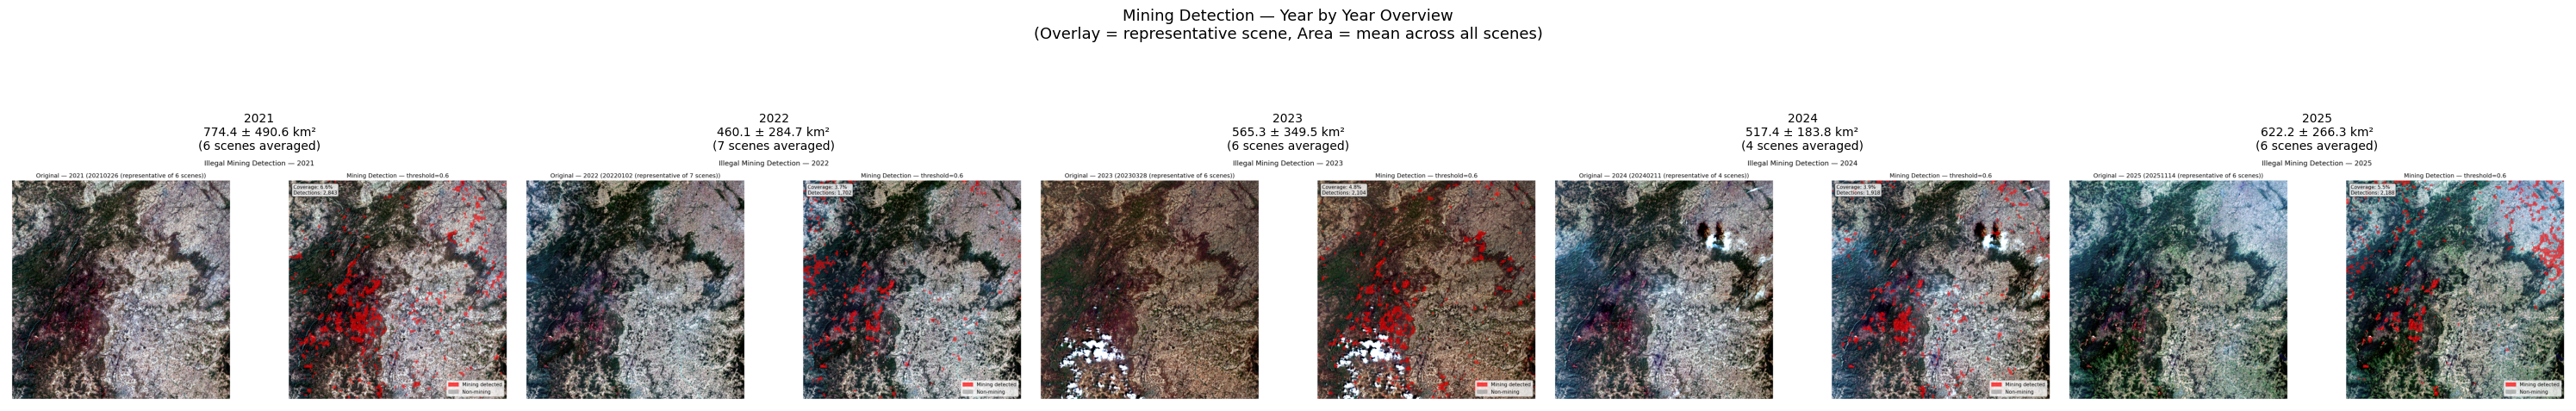

Saved: inference_output/temporal\all_years_overview.png


In [7]:
if yearly_results:
    n = len(yearly_results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]

    for ax, res in zip(axes, yearly_results):
        img_path = os.path.join(OUTPUT_DIR, f'{res["year"]}_overlay.png')
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path))
            title = (f'{res["year"]}\n'
                     f'{res["area_km2"]:.1f} ± {res["area_km2_std"]:.1f} km²\n'
                     f'({res["n_scenes"]} scenes averaged)')
            ax.set_title(title, fontsize=10)
        else:
            ax.text(0.5, 0.5, f'{res["year"]}\nNo overlay',
                    ha='center', va='center', fontsize=11)
        ax.axis('off')

    plt.suptitle('Mining Detection — Year by Year Overview\n'
                 '(Overlay = representative scene, Area = mean across all scenes)',
                 fontsize=13)
    plt.tight_layout()
    overview_path = os.path.join(OUTPUT_DIR, 'all_years_overview.png')
    plt.savefig(overview_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {overview_path}')
